In [1]:
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from rasterio.plot import show

#Read AOI

In [2]:
folder = Path("/content/drive/MyDrive/Track-2 Assignment data")

In [3]:
JBP = gpd.read_file("/content/drive/MyDrive/Track-2 Assignment data/JBP.geojson")
print("JBP crs:", JBP.crs)

JBP crs: EPSG:3857


#Plot AOI

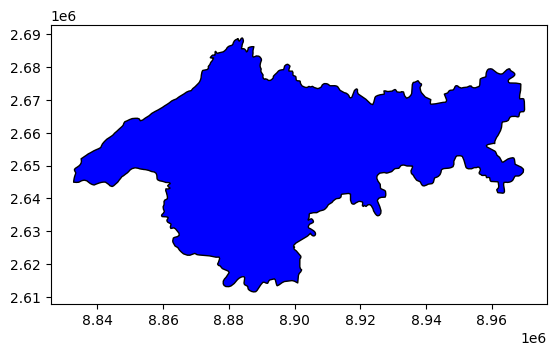

In [4]:
x = JBP.plot(color= "blue", edgecolor= "black")

#Read both landsat bands tile

In [5]:
red1 = folder/ "/content/drive/MyDrive/Track-2 Assignment data/JBP NDVI 2020/T1/LC08_L2SP_144044_20200518_20200820_02_T1_SR_B4.TIF"
red2 = folder/ "/content/drive/MyDrive/Track-2 Assignment data/JBP NDVI 2020/T2/LC08_L2SP_143044_20200527_20200820_02_T1_SR_B4.TIF"

In [6]:
NIR1 = folder/ "/content/drive/MyDrive/Track-2 Assignment data/JBP NDVI 2020/T1/LC08_L2SP_144044_20200518_20200820_02_T1_SR_B5.TIF"
NIR2 = folder/ "/content/drive/MyDrive/Track-2 Assignment data/JBP NDVI 2020/T2/LC08_L2SP_143044_20200527_20200820_02_T1_SR_B5.TIF"

#Check Bands CRS

In [7]:
with rasterio.open(red1) as src:
    print("red1 CRS:", src.crs)

with rasterio.open(red2) as src:
    print("red2 CRS:", src.crs)

red1 CRS: EPSG:32644
red2 CRS: EPSG:32644


In [8]:
with rasterio.open(NIR1) as src:
    print("NIR1 CRS:", src.crs)

with rasterio.open(NIR2) as src:
    print("NIR2 CRS:", src.crs)

NIR1 CRS: EPSG:32644
NIR2 CRS: EPSG:32644


# Change CRS

In [9]:
JBP = JBP.to_crs(epsg=32644)
print(JBP.crs)

EPSG:32644


#Mosaic both tile bands together

In [10]:
from rasterio.merge import merge

reds = [rasterio.open(red1), rasterio.open(red2) ]

red_mosaic, out_transform = merge(reds)

In [11]:
from rasterio.merge import merge

NIRS = [rasterio.open(NIR1), rasterio.open(NIR2) ]

NIR_mosaic, out_transform = merge(NIRS)

#Plot Mosaic bands

In [12]:
import matplotlib.pyplot as plt

In [13]:
print(red_mosaic.shape)

(1, 7821, 12961)


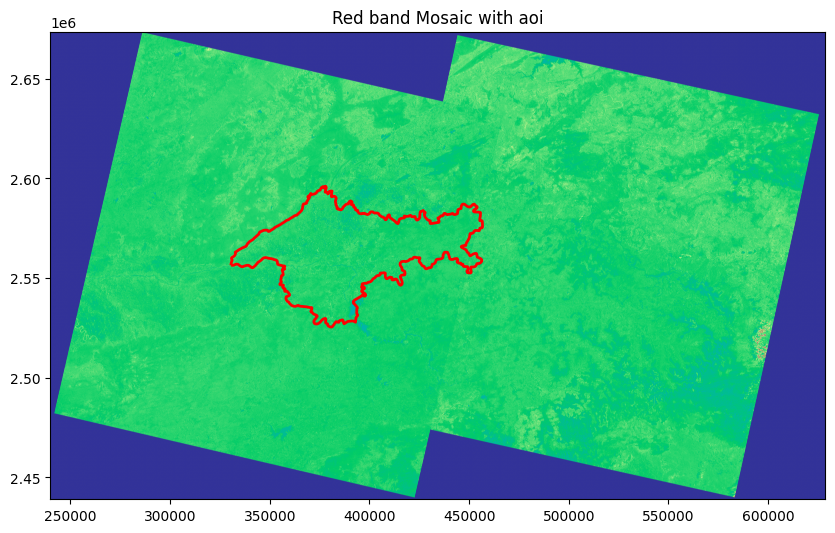

In [14]:
import rasterio.plot
fig, ax= plt.subplots(figsize=(10,10))
rasterio.plot.show(red_mosaic,
                   transform= out_transform,
                   ax=ax,
                   cmap= 'terrain')
JBP.boundary.plot(ax=ax, edgecolor='red', linewidth=2)
plt.title("Red band Mosaic with aoi")
plt.show()

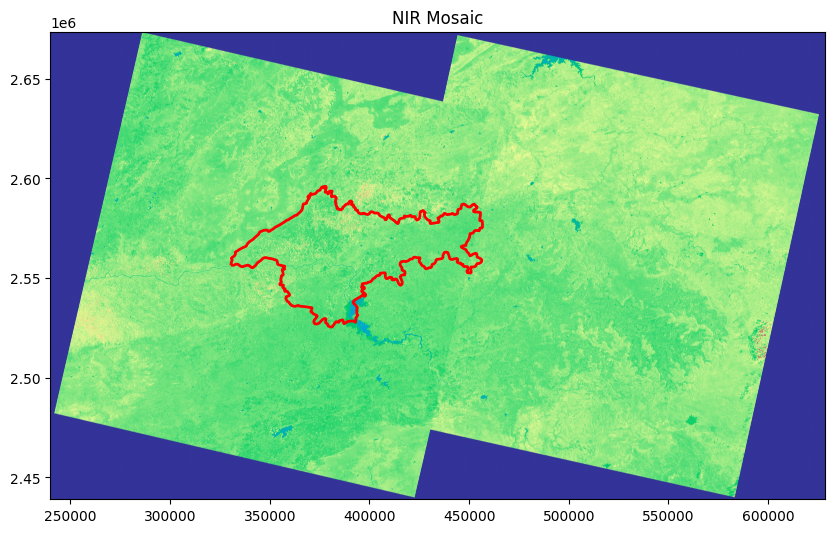

In [15]:
import rasterio.plot
fig, ax= plt.subplots(figsize=(10,10))
rasterio.plot.show(NIR_mosaic,
                   transform= out_transform,
                   ax=ax,
                   cmap= 'terrain')
JBP.boundary.plot(ax=ax, edgecolor='red', linewidth=2)
plt.title("NIR Mosaic")
plt.show()

#Save output

In [16]:
with rasterio.open(red1) as src:
    out_meta = src.meta.copy()

out_meta.update({
    "height": red_mosaic.shape[1],
    "width": red_mosaic.shape[2],
    "transform": out_transform,
    "count": 1,
    "dtype": "float32"
})

with rasterio.open(folder/"red_mosaic.tif", "w", **out_meta) as dst:
    dst.write(red_mosaic)

In [17]:
with rasterio.open(NIR1) as src:
    out_meta = src.meta.copy()

out_meta.update({
    "height": NIR_mosaic.shape[1],
    "width": NIR_mosaic.shape[2],
    "transform": out_transform,
    "count": 1,
    "dtype": "float32"
})

with rasterio.open(folder/"NIR_mosaic.tif", "w", **out_meta) as dst:
    dst.write(NIR_mosaic)

#Clip mosaics using AOI

In [18]:
geoms = JBP.geometry
geoms

,geometry
0,"MULTIPOLYGON (((378350.797 2595284.358, 378293..."


In [19]:
from rasterio.mask import mask

with rasterio.open(folder / "red_mosaic.tif") as ds:

    red_clip, clip_transform = mask(
        ds,
        JBP.geometry,
        crop=True
    )

In [20]:
out_meta = ds.meta.copy()
out_meta.update({"height":red_clip.shape[1],
                 "width":red_clip.shape[2],
                 "transform":clip_transform
                  })

with rasterio.open(folder/"red_clip.tif", "w", **out_meta) as dest:
    dest.write(red_clip)

#NIR Clip

In [21]:
from rasterio.mask import mask

with rasterio.open(folder / "NIR_mosaic.tif") as ds:

    NIR_clip, NIR_transform = mask(
        ds,
        JBP.geometry,
        crop=True
    )

In [22]:
out_meta = ds.meta.copy()
out_meta.update({"height":NIR_clip.shape[1],
                 "width":NIR_clip.shape[2],
                 "transform":clip_transform
                  })

with rasterio.open(folder/"NIR_clip.tif", "w", **out_meta) as dest:
    dest.write(NIR_clip)

#Plot band clip

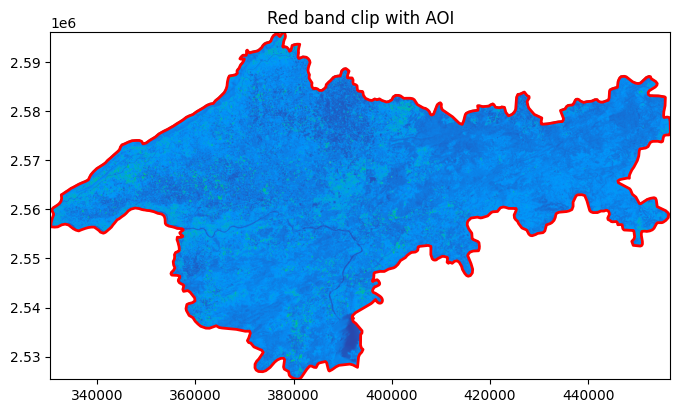

In [23]:
with rasterio.open(folder/"red_clip.tif") as ds:
  fig, ax= plt.subplots(figsize=(8,8))
  rasterio.plot.show(ds, ax=ax, cmap='terrain')
  JBP.boundary.plot(ax=ax, edgecolor='red', linewidth=2)
  plt.title("Red band clip with AOI")
  plt.show()

#JBP NDVI Calculation year 2020

In [24]:
red = red_clip.astype("float32")
NIR = NIR_clip.astype("float32")

In [25]:
red = red * 0.0000275 - 0.2   #This line converts the raw digital numbers (DN) into actual surface reflectance values.
NIR = NIR * 0.0000275 - 0.2


In [26]:
NDVI2020 = (NIR - red) / (NIR + red)

#Avoid division by zero

In [27]:
NDVI2020[(NIR + red) == 0] = np.nan

#save output

In [28]:
output_path = "/content/drive/MyDrive/Track-2 Assignment data/JBP_NDVI.tif"

out_meta.update({
    "driver": "GTiff",
    "height": NDVI2020.shape[1],
    "width": NDVI2020.shape[2],
    "transform": clip_transform,
    "count": 1,
    "dtype": "float32"
})
with rasterio.open(output_path, "w", **out_meta) as dst:
    dst.write(NDVI2020.astype("float32"))

#Plot NDVI

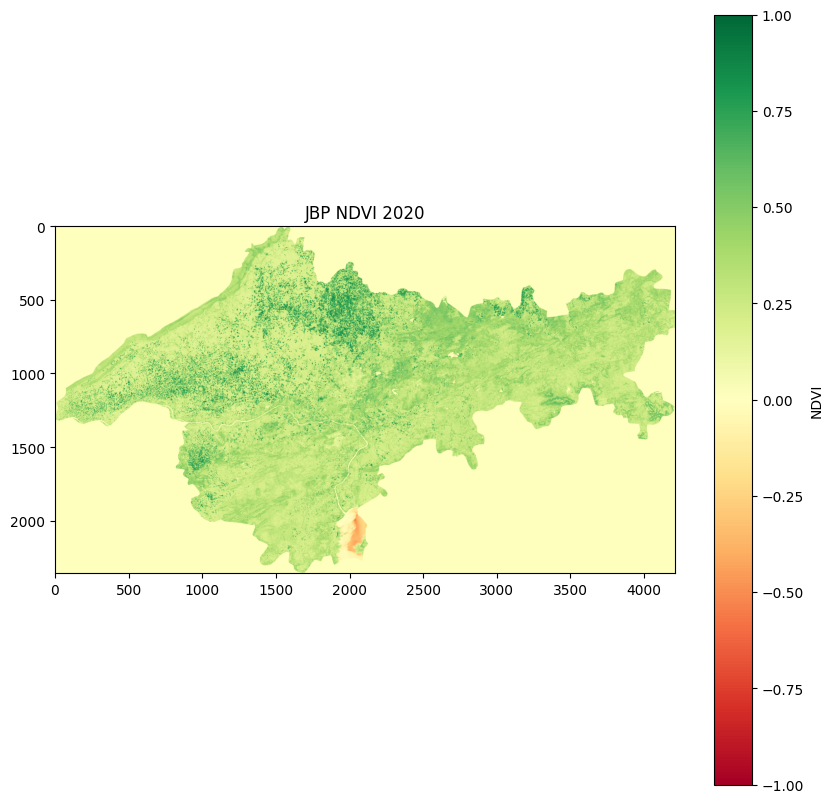

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

plt.imshow(NDVI2020[0], cmap="RdYlGn", vmin=-1, vmax=1)

plt.colorbar(label="NDVI")

plt.title("JBP NDVI 2020")

plt.show()

#Classify 2020 JBP NDVI

In [30]:
water_2020 = np.sum(NDVI2020 < 0)
sparse_2020 = np.sum((NDVI2020 >= 0) & (NDVI2020 < 0.2))
moderate_2020 = np.sum((NDVI2020 >= 0.2) & (NDVI2020 < 0.5))
dense_2020 = np.sum(NDVI2020 >= 0.5)

In [31]:
print("Water/Bare/Built-up :", water_2020)
print("Sparse :", sparse_2020)
print("Moderate :", moderate_2020)
print("Dense :", dense_2020)

Water/Bare/Built-up : 52507
Sparse : 5960346
Moderate : 3399045
Dense : 504506


#Convert pixel to area for Area calculation
for landsat Pixel size = 30 × 30 m
1 pixel = 0.0009 km²

In [32]:
pixel_area = 30 * 30

pixel_area_km2 = pixel_area / 1e6

In [33]:
water_area_2020 = water_2020 * pixel_area_km2

sparse_area_2020  = sparse_2020 * pixel_area_km2

moderate_area_2020 = moderate_2020 * pixel_area_km2

dense_area_2020 = dense_2020 * pixel_area_km2

#Display the Area statistics

In [34]:
print(f"Water/Bare/Built-up  : {water_area_2020:.2f} km²")
print(f"Sparse Vegetation : {sparse_area_2020:.2f} km²")
print(f"Moderate Vegetation : {moderate_area_2020:.2f} km²")
print(f"Dense Vegetation : {dense_area_2020:.2f} km²")

Water/Bare/Built-up  : 47.26 km²
Sparse Vegetation : 5364.31 km²
Moderate Vegetation : 3059.14 km²
Dense Vegetation : 454.06 km²


#Creating a DataFrame

In [35]:
import pandas as pd

In [36]:

stats = pd.DataFrame({
    "Class": [
        "Water/Bare/Built-up ",
        "Sparse Vegetation",
        "Moderate Vegetation",
        "Dense Vegetation"],

    "Area (km²)": [water_area_2020,
        sparse_area_2020 ,
        moderate_area_2020,
        dense_area_2020]})
stats


,Class,Area (km²)
0,Water/Bare/Built-up,47.2563
1,Sparse Vegetation,5364.3114
2,Moderate Vegetation,3059.1405
3,Dense Vegetation,454.0554


#save CSV table

In [37]:
stats.to_csv("NDVI_Area_Statistics_2020.csv", index=False)

#Now Calculate JBP NDVI for year 2025

In [38]:
Red1 = folder/ "/content/drive/MyDrive/Track-2 Assignment data/JBP NDVI 2025/T1/LC08_L2SP_143044_20250423_20250429_02_T1_SR_B4.TIF"
Red2 = folder/ "/content/drive/MyDrive/Track-2 Assignment data/JBP NDVI 2025/T2/LC09_L2SP_144044_20250422_20250423_02_T1_SR_B4.TIF"

In [39]:
NIR1 = folder/"/content/drive/MyDrive/Track-2 Assignment data/JBP NDVI 2025/T1/LC08_L2SP_143044_20250423_20250429_02_T1_SR_B5.TIF"
NIR2 = folder/"/content/drive/MyDrive/Track-2 Assignment data/JBP NDVI 2025/T2/LC09_L2SP_144044_20250422_20250423_02_T1_SR_B5.TIF"

#Again check CRS for 2025 image

In [40]:
with rasterio.open(Red1) as src:
    print("Red1 CRS:", src.crs)

with rasterio.open(Red2) as src:
    print("Red2 CRS:", src.crs)

Red1 CRS: EPSG:32644
Red2 CRS: EPSG:32644


In [41]:
with rasterio.open(NIR1) as src:
    print(" NIR1 CRS:", src.crs)

with rasterio.open(NIR2) as src:
    print("NIR2 CRS:", src.crs)

 NIR1 CRS: EPSG:32644
NIR2 CRS: EPSG:32644


#Mosaic both 2025 tile bands

In [42]:
from rasterio.merge import merge

Reds = [rasterio.open(Red1), rasterio.open(Red2) ]

Red_mosaic, out_transform = merge(Reds)

In [43]:
from rasterio.merge import merge

NIRS = [rasterio.open(NIR1), rasterio.open(NIR2) ]

NIR_mosaic, out_transform = merge(NIRS)

#Save 2025 mosaic tiles

In [44]:
with rasterio.open(Red1) as src:
    out_meta = src.meta.copy()

out_meta.update({
    "height": Red_mosaic.shape[1],
    "width": Red_mosaic.shape[2],
    "transform": out_transform,
    "count": 1,
    "dtype": "float32"
})

with rasterio.open(folder/"Red_mosaic(2025).tif", "w", **out_meta) as dst:
    dst.write(Red_mosaic)

In [45]:
with rasterio.open(NIR1) as src:
    out_meta = src.meta.copy()

out_meta.update({
    "height": NIR_mosaic.shape[1],
    "width": NIR_mosaic.shape[2],
    "transform": out_transform,
    "count": 1,
    "dtype": "float32"
})

with rasterio.open(folder/"NIR_mosaic(2025).tif", "w", **out_meta) as dst:
    dst.write(NIR_mosaic)

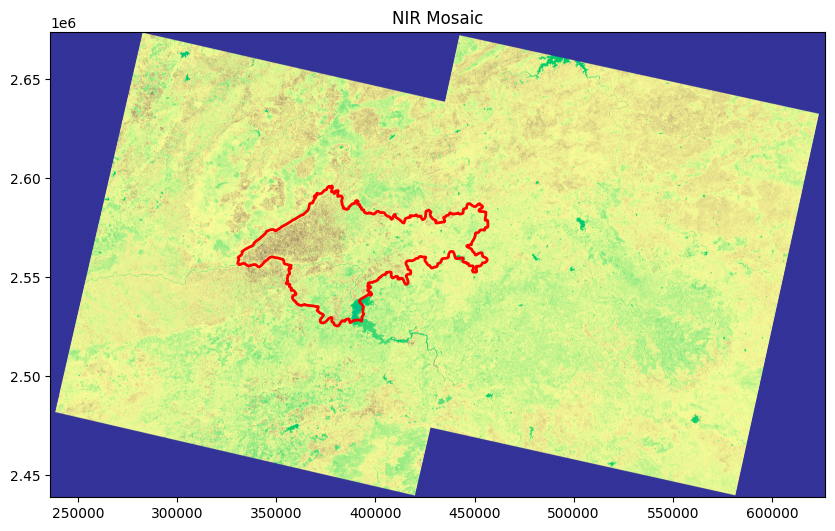

In [46]:
import rasterio.plot
fig, ax= plt.subplots(figsize=(10,10))
rasterio.plot.show(NIR_mosaic,
                   transform= out_transform,
                   ax=ax,
                   cmap= 'terrain')
JBP.boundary.plot(ax=ax, edgecolor='red', linewidth=2)
plt.title("NIR Mosaic")
plt.show()

#Clip Mosaic for 2025 image

In [47]:
from rasterio.mask import mask

with rasterio.open(folder / "Red_mosaic(2025).tif") as ds:

    Red_clip, clip_transform = mask(
        ds,
        JBP.geometry,
        crop=True
    )

In [48]:
from rasterio.mask import mask

with rasterio.open(folder / "NIR_mosaic(2025).tif") as ds:

    NIR_clip, clip_transform = mask(
        ds,
        JBP.geometry,
        crop=True
    )

#save clip output

In [49]:
out_meta = ds.meta.copy()
out_meta.update({"height":Red_clip.shape[1],
                 "width":Red_clip.shape[2],
                 "transform":clip_transform
                  })

with rasterio.open(folder/"Red_clip(2025).tif", "w", **out_meta) as dest:
    dest.write(Red_clip)

In [50]:
out_meta = ds.meta.copy()
out_meta.update({"height":NIR_clip.shape[1],
                 "width":NIR_clip.shape[2],
                 "transform":clip_transform
                  })

with rasterio.open(folder/"NIR_clip(2025).tif", "w", **out_meta) as dest:
    dest.write(NIR_clip)

#Plot 2025 clipped image

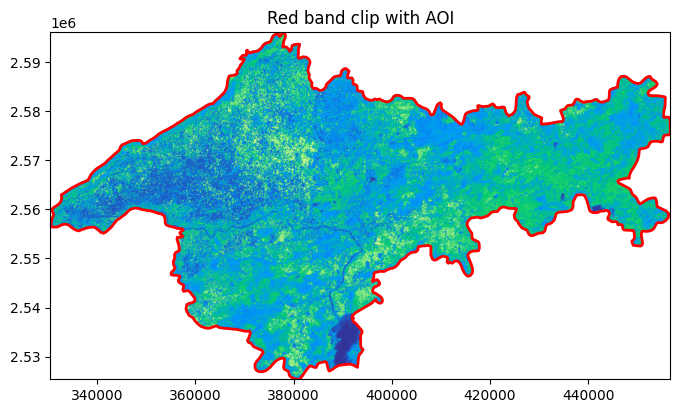

In [51]:
with rasterio.open(folder/"Red_clip(2025).tif") as ds:
  fig, ax= plt.subplots(figsize=(8,8))
  rasterio.plot.show(ds, ax=ax, cmap='terrain')
  JBP.boundary.plot(ax=ax,
                    edgecolor='red',
                    linewidth=2)
  plt.title("Red band clip with AOI")
  plt.show()

#NDVI Calculation year 2025

In [52]:
Red = Red_clip.astype("float32")
NIR = NIR_clip.astype("float32")

In [53]:
Red = Red * 0.0000275 - 0.2   #This line converts the raw digital numbers (DN) into actual surface reflectance values.
NIR = NIR * 0.0000275 - 0.2


In [54]:
NDVI2025 = (NIR - Red) / (NIR + Red)

#Avoid division by zero

In [55]:
NDVI2025[(NIR + Red) == 0] = np.nan

#Save 2025 NDVI

In [56]:
output_path = "/content/drive/MyDrive/Track-2 Assignment data/JBP_NDVI 2025.tif"

out_meta.update({
    "driver": "GTiff",
    "height": NDVI2025.shape[1],
    "width": NDVI2025.shape[2],
    "transform": clip_transform,
    "count": 1,
    "dtype": "float32"
})
with rasterio.open(output_path, "w", **out_meta) as dst:
    dst.write(NDVI2025.astype("float32"))

#Plot 2025 NDVI Image

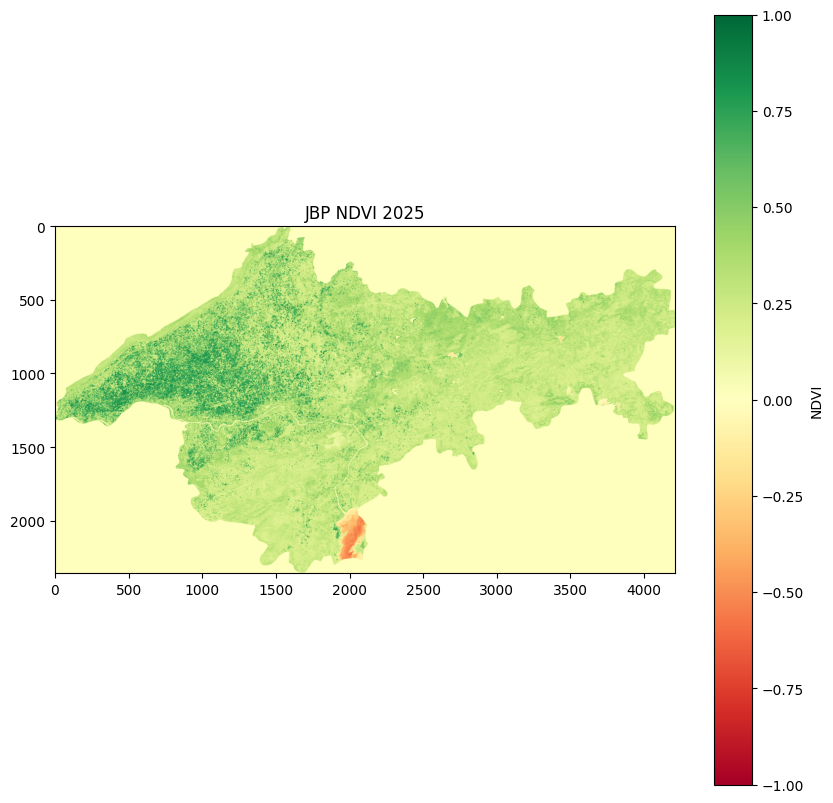

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

plt.imshow(NDVI2025[0], cmap="RdYlGn", vmin=-1, vmax=1)

plt.colorbar(label="NDVI")

plt.title("JBP NDVI 2025")

plt.show()

#Classify 2025 JBP NDVI

In [58]:
water_2025 = np.sum(NDVI2025 < 0)
sparse_2025 = np.sum((NDVI2025 >= 0) & (NDVI2025 < 0.2))
moderate_2025 = np.sum((NDVI2025 >= 0.2) & (NDVI2025 < 0.5))
dense_2025 = np.sum(NDVI2025 >= 0.5)

In [59]:
print("Water/Bare/Built-up  :", water_2025)
print("Sparse :", sparse_2025)
print("Moderate :", moderate_2025)
print("Dense :", dense_2025)

Water/Bare/Built-up  : 60522
Sparse : 5869746
Moderate : 3376550
Dense : 609586


#Convert pixels to area for Area calculation
for landsat pixel size = 30 × 30 m
1 pixel = 0.0009 km²

In [60]:
pixel_area = 30 * 30

pixel_area_km2 = pixel_area / 1e6

In [61]:
water_area_2025 = water_2025 * pixel_area_km2

sparse_area_2025 = sparse_2025 * pixel_area_km2

moderate_area_2025 = moderate_2025 * pixel_area_km2

dense_area_2025 = dense_2025 * pixel_area_km2

In [62]:
print(f"Water/Bare/Built-up  : {water_area_2025:.2f} km²")
print(f"Sparse Vegetation : {sparse_area_2025:.2f} km²")
print(f"Moderate Vegetation : {moderate_area_2025:.2f} km²")
print(f"Dense Vegetation : {dense_area_2025:.2f} km²")

Water/Bare/Built-up  : 54.47 km²
Sparse Vegetation : 5282.77 km²
Moderate Vegetation : 3038.89 km²
Dense Vegetation : 548.63 km²


#create DataFrame for 2025 NDVI

In [63]:
import pandas as pd

stats = pd.DataFrame({
    "Class": [
        "Water/Bare/Built-up ",
        "Sparse_area",
        "Moderate_area",
        "Dense Vegetation"
    ],
    "Area (km²)": [
        water_area_2025,
        sparse_area_2025 ,
        moderate_area_2025,
        dense_area_2025
    ]
})

stats

,Class,Area (km²)
0,Water/Bare/Built-up,54.4698
1,Sparse_area,5282.7714
2,Moderate_area,3038.8950
3,Dense Vegetation,548.6274


#save CSV table

In [64]:
stats.to_csv("NDVI_Area_Statistics_2025.csv", index=False)

#Area statics comparison btw 2020 vs 2025 NDVI

In [65]:
comparison = pd.DataFrame({
    "Class": [
        "Water/Bare/Built-up ",
        "Sparse Vegetation",
        "Moderate Vegetation",
        "Dense Vegetation"
    ],
    "2020 (km²)": [
        water_area_2020,
        sparse_area_2020 ,
        moderate_area_2020,
        dense_area_2020
    ],
    "2025 (km²)": [
         water_area_2025,
        sparse_area_2025 ,
        moderate_area_2025,
        dense_area_2025
    ]

})

comparison["Change (km²)"] = comparison["2025 (km²)"] - comparison["2020 (km²)"]

comparison

,Class,2020 (km²),2025 (km²),Change (km²)
0,Water/Bare/Built-up,47.2563,54.4698,7.2135
1,Sparse Vegetation,5364.3114,5282.7714,-81.5400
2,Moderate Vegetation,3059.1405,3038.8950,-20.2455
3,Dense Vegetation,454.0554,548.6274,94.5720


In [68]:
stats.to_csv("NDVI_Area_Statistics_comparison.csv", index=False)

#NDVI Change Detection Between 2020 and 2025

In [ ]:

NDVI2020 = rasterio.open("/content/drive/MyDrive/Track-2 Assignment data/JBP_NDVI.tif")
NDVI2025 = rasterio.open("/content/drive/MyDrive/Track-2 Assignment data/JBP_NDVI 2025.tif")

In [ ]:
with rasterio.open("/content/drive/MyDrive/Track-2 Assignment data/JBP_NDVI.tif") as src:
    NDVI2020 = src.read(1)

with rasterio.open("/content/drive/MyDrive/Track-2 Assignment data/JBP_NDVI 2025.tif") as src:
    NDVI2025 = src.read(1)

    print(src.crs)
    print(src.transform)
    print(src.width)
    print(src.height)

EPSG:32644
| 30.00, 0.00, 330495.00|
| 0.00,-30.00, 2596065.00|
| 0.00, 0.00, 1.00|
4209
2356


#Calculate NDVI change between 2k20 & 2k25

In [ ]:
NDVI_Change = NDVI2025 - NDVI2020

#save output

In [ ]:
output_path = "/content/drive/MyDrive/Track-2 Assignment data/NDVI_Change_2020_2025.tif"

out_meta.update({
    "driver": "GTiff",
    "height": NDVI_Change.shape[0],
    "width": NDVI_Change.shape[1],
    "transform": out_transform,
    "count": 1,
    "dtype": "float32"
})

with rasterio.open(output_path, "w", **out_meta) as dst:
    dst.write(NDVI_Change.astype("float32"), 1)


#Plot NDVI change

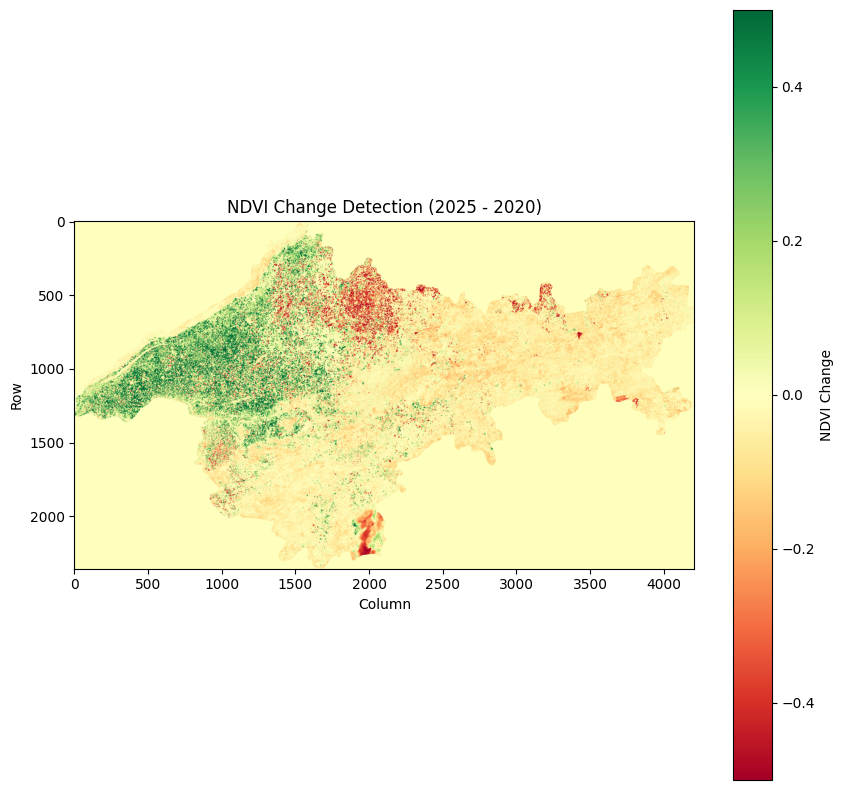

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

plt.imshow(NDVI_Change, cmap="RdYlGn",  vmin=-0.5,
    vmax=0.5)
plt.colorbar(label="NDVI Change")

plt.title("NDVI Change Detection (2025 - 2020)")
plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

red = vegetation loss

green = vegetation gain

yellow = Little or no change

